In [9]:
import numpy as np

# -------------------------
# 1) Time settings
# -------------------------
CONTROL_HORIZON = 1
PREDICTION_HORIZON = 12
T_TOTAL = 168  # 1 week, 1-hour steps

DT_HOURS = 1.0  # timestep duration

# -------------------------
# 2) System parameters (physical)
# -------------------------
ETA_CH = 0.95
ETA_DCH = 0.95

KWH_PER_KG = 50.0                 # ~48–55 kWh/kg typical
ETA_ELEC = (DT_HOURS / KWH_PER_KG)  # kg per timestep per kW (since 1kW*1h=1kWh)

SOC_MAX = 1000.0   # kWh
P_BAT_MAX = 200.0  # kW
P_ELEC_MAX = 300.0 # kW
H_STORE_MAX = 1000.0  # kg

# Hydrogen storage throughput (kg/h)
H_CH_MAX = 10.0
H_DCH_MAX = 10.0

# Electrolyzer operational constraints
P_ELEC_MIN = 0.2 * P_ELEC_MAX  # kW
RAMP_MAX = 60.0                # kW per hour

# Grid import limit (kW)
P_GRID_MAX = 250.0

# -------------------------
# 3) Economics (units aligned)
# -------------------------
# prices are now in $/kWh and $/kg
# -------------------------
C_GRID_BASE = 40.0      # (can be removed if unused)
# Battery degradation / throughput cost (very rough)
C_BATTERY = 0.03    # $/kWh throughput (charge+discharge)

# Electrolyzer variable O&M (water, maintenance per kWh electricity input)
C_ELEC = 0.01       # $/kWh (can be 0.005–0.02)

# Storage holding cost per kg per hour (should be tiny)
C_HSTORE = 0.0005   # $/(kg·hour)  (0.0001–0.001)

# Hydrogen sale price
H_PRICE = 10.0       # $/kg (try 7–12 depending on scenario)

# Carbon adder
CO2_ADDER = 0.02    # $/kWh (fine)

# -------------------------
# 4) Initial states
# -------------------------
SOC_INIT = 500.0
H_STORE_INIT = 20

# -------------------------
# 5) RNGs for disturbances (DO NOT re-init inside functions)
# -------------------------
_SOLAR_RNG = np.random.default_rng(0)
_PRICE_RNG = np.random.default_rng(1)
_DEMAND_RNG = np.random.default_rng(2)

# -------------------------
# 6) Real-time disturbance models (truth signals)
# -------------------------
def real_solar(t: int) -> float:
    """
    PV power available at time t [kW].
    Day/night half-sine + slow cloudiness + small noise.
    """
    hod = t % 24
    if hod < 6 or hod > 18:
        base = 0.0
    else:
        x = (hod - 6) / 12.0
        base = np.sin(np.pi * x)

    P_PV_PEAK = 300
    day = t // 24
    cloud = 0.75 + 0.20 * np.sin(2*np.pi*day/7.0)
    noise = _SOLAR_RNG.normal(0.0, 0.03)

    return float(max(0.0, P_PV_PEAK * base * (cloud + noise)))

def real_grid_price(t: int) -> float:
    """
    Electricity price [$/kWh].
    Time-of-use + rare spikes.
    """
    hod = t % 24
    if 0 <= hod < 6:
        p = 0.08
    elif 6 <= hod < 16:
        p = 0.12
    elif 16 <= hod < 21:
        p = 0.28
    else:
        p = 0.15

    # 2% spike chance
    if _PRICE_RNG.random() < 0.02:
        p *= 2.5

    return float(p)

def real_hydrogen_demand(t: int) -> float:
    """
    Hydrogen demand [kg/h] at time t.
    Scaled to match 300 kW electrolyzer (~6 kg/h max).
    """
    hod = t % 24
    base = 3.5 + 1.5*np.sin(2*np.pi*(hod-8)/24.0)  # ~2..5
    day = t // 24
    weekly = 0.3*np.sin(2*np.pi*day/7.0)
    noise = _DEMAND_RNG.normal(0.0, 0.25)

    return float(max(0.0, base + weekly + noise))

# -------------------------
# 7) Forecast model (used by MPC and RL+Forecast)
# -------------------------
# Separate sigmas per signal (scaled to units!)
SIGMA_SOLAR0 = 10.0   # kW
SIGMA_PRICE0 = 0.02   # $/kWh
SIGMA_DEMAND0 = 0.5   # kg/h
ALPHA = 0.8

def forecast_with_uncertainty(real_func, t_now: int, delta: int, rng: np.random.Generator, sigma0: float):
    """
    Forecast for time t_now+delta with uncertainty increasing in delta.
    """
    std = float(sigma0 * np.sqrt(1.0 + ALPHA * float(delta)))
    value = float(real_func(t_now + delta) + rng.normal(0.0, std))
    return value, std

# -------------------------
# 7) Common logger + KPI tools
# -------------------------
def init_logs():
    """
    Standardized logging schema used by all methods.
    Keys MUST match across RBC/MPC/RL for apples-to-apples KPI computation.
    """
    return {k: [] for k in [
        "E_sb","E_be","E_ge","P_elec",
        "H_prod","H_sales","H_es","H_est","H_ss",
        "SOC","H_store","solar"
    ]}

def compute_kpis(logs: dict) -> dict:
    """
    Compute standardized KPIs from logs (same for RBC, MPC, RL).

    Assumes logs contain T steps for decision variables and pre-update states.
    """
    time = np.arange(len(logs["E_sb"]))

    E_sb = np.asarray(logs["E_sb"], dtype=float)
    E_be = np.asarray(logs["E_be"], dtype=float)
    E_ge = np.asarray(logs["E_ge"], dtype=float)
    P_elec = np.asarray(logs["P_elec"], dtype=float)

    H_prod = np.asarray(logs["H_prod"], dtype=float)
    H_sales = np.asarray(logs["H_sales"], dtype=float)
    H_es = np.asarray(logs["H_es"], dtype=float)
    H_est = np.asarray(logs["H_est"], dtype=float)
    H_ss = np.asarray(logs["H_ss"], dtype=float)

    H_store = np.asarray(logs["H_store"], dtype=float)

    # ENERGY METRICS
    solar_to_battery = float(np.sum(E_sb))
    # Approx solar used in electrolyzer: P_elec minus non-solar contributions (battery discharge + grid)
    solar_to_electrolyzer = float(np.sum(P_elec - E_be - E_ge))
    battery_discharge = float(np.sum(E_be))
    grid_energy = float(np.sum(E_ge))
    electrolyzer_energy = float(np.sum(P_elec))

    # HYDROGEN METRICS
    hydrogen_produced = float(np.sum(H_prod))
    hydrogen_sold_total = float(np.sum(H_sales))
    hydrogen_sold_from_prod = float(np.sum(H_es))
    hydrogen_sold_from_storage = float(np.sum(H_ss))
    hydrogen_to_storage = float(np.sum(H_est))

    # COSTS
    grid_prices = np.array([real_grid_price(int(t)) for t in time], dtype=float)
    grid_cost = float(np.sum(E_ge * (grid_prices + CO2_ADDER)))
    battery_cost = float(np.sum(C_BATTERY * (E_sb + E_be)))
    electrolyzer_cost = float(np.sum(C_ELEC * P_elec))
    storage_cost = float(np.sum(C_HSTORE * H_store))
    total_cost = float(grid_cost + battery_cost + electrolyzer_cost + storage_cost)

    # REVENUE & PROFIT
    revenue = float(np.sum(H_PRICE * H_sales))
    net_profit = float(revenue - total_cost)

    kpis = {
        # Energy
        "Solar Used (E_se)": solar_to_electrolyzer,
        "Grid Energy Used (E_ge)": grid_energy,
        "Battery Charge (E_sb)": solar_to_battery,
        "Battery Discharge (E_be)": battery_discharge,
        "Electrolyzer Energy": electrolyzer_energy,

        # Hydrogen
        "Hydrogen Produced": hydrogen_produced,
        "Hydrogen Sold (Total)": hydrogen_sold_total,
        "Hydrogen Sold from Production (H_es)": hydrogen_sold_from_prod,
        "Hydrogen Sold from Storage (H_ss)": hydrogen_sold_from_storage,
        "Hydrogen Stored (H_est)": hydrogen_to_storage,

        # Economics
        "Revenue ($)": revenue,
        "Grid Cost ($)": grid_cost,
        "Battery Cost ($)": battery_cost,
        "Electrolyzer Cost ($)": electrolyzer_cost,
        "Storage Cost ($)": storage_cost,
        "Total Cost ($)": total_cost,
        "Net Profit ($)": net_profit,

        # Efficiency
        "H₂ Utilization (%)": float(100 * hydrogen_sold_total / (hydrogen_produced + H_STORE_INIT)) if hydrogen_produced > 0 else 0.0
    }
    return kpis

def plot_kpis(kpi_values: dict, title_suffix: str = "") -> None:
    """
    Publication-ready KPI plots.
    - Removes efficiency panel
    - Thicker bars
    - Lighter grid
    - Cleaner annotations
    """

    import matplotlib.pyplot as plt

    # ---- Categories (Efficiency removed) ----
    categories = {
        "Energy (kWh)": [
            "Solar Used (E_se)", "Grid Energy Used (E_ge)",
            "Battery Charge (E_sb)", "Battery Discharge (E_be)",
            "Electrolyzer Energy"
        ],
        "Hydrogen (kg)": [
            "Hydrogen Produced", "Hydrogen Sold (Total)",
            "Hydrogen Sold from Production (H_es)",
            "Hydrogen Sold from Storage (H_ss)",
            "Hydrogen Stored (H_est)"
        ],
        "Cost & Revenue ($)": [
            "Revenue ($)", "Grid Cost ($)", "Battery Cost ($)",
            "Electrolyzer Cost ($)", "Storage Cost ($)",
            "Total Cost ($)", "Net Profit ($)"
        ]
    }

    # Slightly more compact than previous version
    fig, axs = plt.subplots(len(categories), 1, figsize=(13, 14))

    if len(categories) == 1:
        axs = [axs]

    for ax, (title, keys) in zip(axs, categories.items()):
        values = [float(kpi_values[k]) for k in keys]

        bars = ax.barh(
            keys,
            values,
            edgecolor="black",
            linewidth=1.2  # thicker edges for print clarity
        )

        ax.set_title(f"{title} {title_suffix}".strip(), fontsize=13)
        ax.set_xlabel(title, fontsize=12)

        # Lighter grid (cleaner for print)
        ax.grid(True, axis="x", linestyle="--", alpha=0.25)
        ax.set_axisbelow(True)

        # Improve readability
        ax.tick_params(axis="y", labelsize=11)
        ax.tick_params(axis="x", labelsize=11)

        # Clean numeric formatting
        for bar in bars:
            width = bar.get_width()

            if abs(width) > 1000:
                label = f"{width:,.0f}"
            elif abs(width) > 10:
                label = f"{width:.1f}"
            else:
                label = f"{width:.2f}"

            ax.text(
                width,
                bar.get_y() + bar.get_height() / 2.0,
                label,
                va="center",
                ha="left",
                fontsize=10
            )

    plt.tight_layout()
    plt.show()

In [10]:
# =====================================================
# B) rbc_controller.py  (METHOD 1: RULE-BASED CONTROL)
# Notebook-friendly, block-by-block
# =====================================================

import numpy as np
import matplotlib.pyplot as plt

# pull everything needed from the shared module namespace (already defined above in the notebook)
# If you're in a notebook, these names already exist; if you're importing, use:
# from common_h2 import (...)

In [11]:
def run_rbc():
    """
    Rule-Based Control (RBC) closed-loop simulation for T_TOTAL steps.
    Minimal upgrades:
      - inventory target band (stabilizes storage behavior)
      - peak-price storage discharge (reduces expensive grid usage)
      - min-load applied only when we intentionally "turn on"
    """
    SOC_real = [float(SOC_INIT)]
    H_store_real = [float(H_STORE_INIT)]
    logs = init_logs()

    P_prev = 0.0

    PRICE_LOW = 0.1
    PRICE_HIGH = 0.2
    SOC_LOW = 0.25 * SOC_MAX
    SOC_HIGH = 0.80 * SOC_MAX
    H_LOW = 0.15 * H_STORE_MAX

    # NEW: storage inventory band
    H_TARGET = 0.30 * H_STORE_MAX
    H_BAND = 0.10 * H_STORE_MAX

    for t in range(T_TOTAL):
        solar = float(real_solar(t))
        price = float(real_grid_price(t))
        demand = float(real_hydrogen_demand(t))

        SOC = float(SOC_real[-1])
        H_store = float(H_store_real[-1])

        E_sb = 0.0
        E_be = 0.0
        E_ge = 0.0
        P_elec = 0.0

        H_es = 0.0
        H_est = 0.0
        H_ss = 0.0

        # A) Electrolyzer target (kW)
        P_need_for_demand = demand / max(ETA_ELEC, 1e-9)
        P_target = min(P_ELEC_MAX, P_need_for_demand)

        # NEW: inventory band logic
        if H_store < (H_TARGET - H_BAND):
            if (price <= PRICE_LOW) or (solar > 50.0):
                P_target = min(P_ELEC_MAX, 1.2 * P_target)
        elif H_store > (H_TARGET + H_BAND):
            P_target = min(P_target, P_need_for_demand)  # meet demand only

        # keep original "low storage buffer"
        if H_store < H_LOW:
            P_target = min(P_ELEC_MAX, 1.2 * P_target)

        # avoid running on expensive grid if storage healthy
        if solar < 5.0 and price >= PRICE_HIGH and H_store > 0.5 * H_STORE_MAX:
            P_target = 0.0

        # ramp limit
        P_target = float(np.clip(P_target, max(0.0, P_prev - RAMP_MAX), min(P_ELEC_MAX, P_prev + RAMP_MAX)))

        # B) PV split: charge battery fraction, rest to electrolyzer
        SOC_headroom = max(SOC_MAX - SOC, 0.0)
        E_sb_cap_soc = SOC_headroom / ETA_CH
        E_sb_cap = min(P_BAT_MAX, E_sb_cap_soc)

        if SOC < SOC_LOW:
            charge_frac = 0.50
        elif SOC < SOC_HIGH:
            charge_frac = 0.20
        else:
            charge_frac = 0.0

        E_sb = min(E_sb_cap, solar * charge_frac)

        pv_to_elec = max(solar - E_sb, 0.0)
        P_elec = min(pv_to_elec, P_target)

        # C) battery discharge if sensible
        want_discharge = (SOC > SOC_LOW) and ((price >= PRICE_HIGH) or (H_store < H_LOW))
        if want_discharge and P_elec < P_target:
            E_be_cap_soc = SOC * ETA_DCH
            E_be_cap = min(P_BAT_MAX, E_be_cap_soc)
            add_batt = min(P_target - P_elec, E_be_cap)
            E_be = add_batt
            P_elec += E_be

        # D) grid only when cheap OR storage critically low
        allow_grid = (price <= PRICE_LOW) or (H_store < H_LOW)
        if allow_grid and P_elec < P_target:
            add_grid = min(P_target - P_elec, P_GRID_MAX)
            E_ge = add_grid
            P_elec += E_ge

        # NEW: min-load only if we intended to be ON (P_target > 0)
        if (P_target > 0.0) and (0.0 < P_elec < P_ELEC_MIN):
            if allow_grid:
                topup = min(P_ELEC_MIN - P_elec, max(0.0, P_GRID_MAX - E_ge))
                E_ge += topup
                P_elec += topup
            else:
                P_elec = 0.0
                E_ge = 0.0
                E_be = 0.0

        # safety caps
        P_elec = float(np.clip(P_elec, 0.0, P_ELEC_MAX))
        E_ge = float(np.clip(E_ge, 0.0, P_GRID_MAX))
        E_sb = float(np.clip(E_sb, 0.0, P_BAT_MAX))
        E_be = float(np.clip(E_be, 0.0, P_BAT_MAX))

        P_prev = P_elec

        # production
        H_prod = float(ETA_ELEC * P_elec)

        # F) allocation
        H_es = min(H_prod, demand)
        demand_left = max(demand - H_es, 0.0)

        # NEW: peak-price discharge more aggressively
        discharge_limit = H_DCH_MAX if price >= PRICE_HIGH else 0.5 * H_DCH_MAX
        H_ss = min(H_store, demand_left, discharge_limit)

        H_sales = H_es + H_ss

        surplus = max(H_prod - H_es, 0.0)
        headroom = max(H_STORE_MAX - H_store, 0.0)
        H_est = min(surplus, headroom, H_CH_MAX)

        # updates
        SOC_new = SOC + ETA_CH * E_sb - E_be / ETA_DCH
        SOC_new = float(np.clip(SOC_new, 0.0, SOC_MAX))

        H_store_new = H_store + H_est - H_ss
        H_store_new = float(np.clip(H_store_new, 0.0, H_STORE_MAX))

        SOC_real.append(SOC_new)
        H_store_real.append(H_store_new)

        # logs (pre-update)
        logs["E_sb"].append(float(E_sb))
        logs["E_be"].append(float(E_be))
        logs["E_ge"].append(float(E_ge))
        logs["P_elec"].append(float(P_elec))
        logs["H_prod"].append(float(H_prod))
        logs["H_sales"].append(float(H_sales))
        logs["H_es"].append(float(H_es))
        logs["H_est"].append(float(H_est))
        logs["H_ss"].append(float(H_ss))
        logs["SOC"].append(float(SOC))
        logs["H_store"].append(float(H_store))
        logs["solar"].append(float(solar))

    return logs

In [12]:
# -------------------------
# Convenience: run + print KPIs + plot
# -------------------------
def demo_rbc():
    """
    Runs RBC, prints KPI summary, and plots KPI bars.
    """
    logs = run_rbc()
    kpis = compute_kpis(logs)

    print("\n===== RBC KPIs =====")
    for k, v in kpis.items():
        print(f"{k:40s}: {v:.2f}")

    plot_kpis(kpis, title_suffix="(RBC)")
    return logs, kpis


===== RBC KPIs =====
Solar Used (E_se)                       : 7504.10
Grid Energy Used (E_ge)                 : 23830.50
Battery Charge (E_sb)                   : 4352.07
Battery Discharge (E_be)                : 4363.99
Electrolyzer Energy                     : 35698.58
Hydrogen Produced                       : 713.97
Hydrogen Sold (Total)                   : 587.63
Hydrogen Sold from Production (H_es)    : 566.01
Hydrogen Sold from Storage (H_ss)       : 21.62
Hydrogen Stored (H_est)                 : 147.96
Revenue ($)                             : 5876.34
Grid Cost ($)                           : 4428.04
Battery Cost ($)                        : 261.48
Electrolyzer Cost ($)                   : 356.99
Storage Cost ($)                        : 8.14
Total Cost ($)                          : 5054.65
Net Profit ($)                          : 821.69
H₂ Utilization (%)                      : 80.06


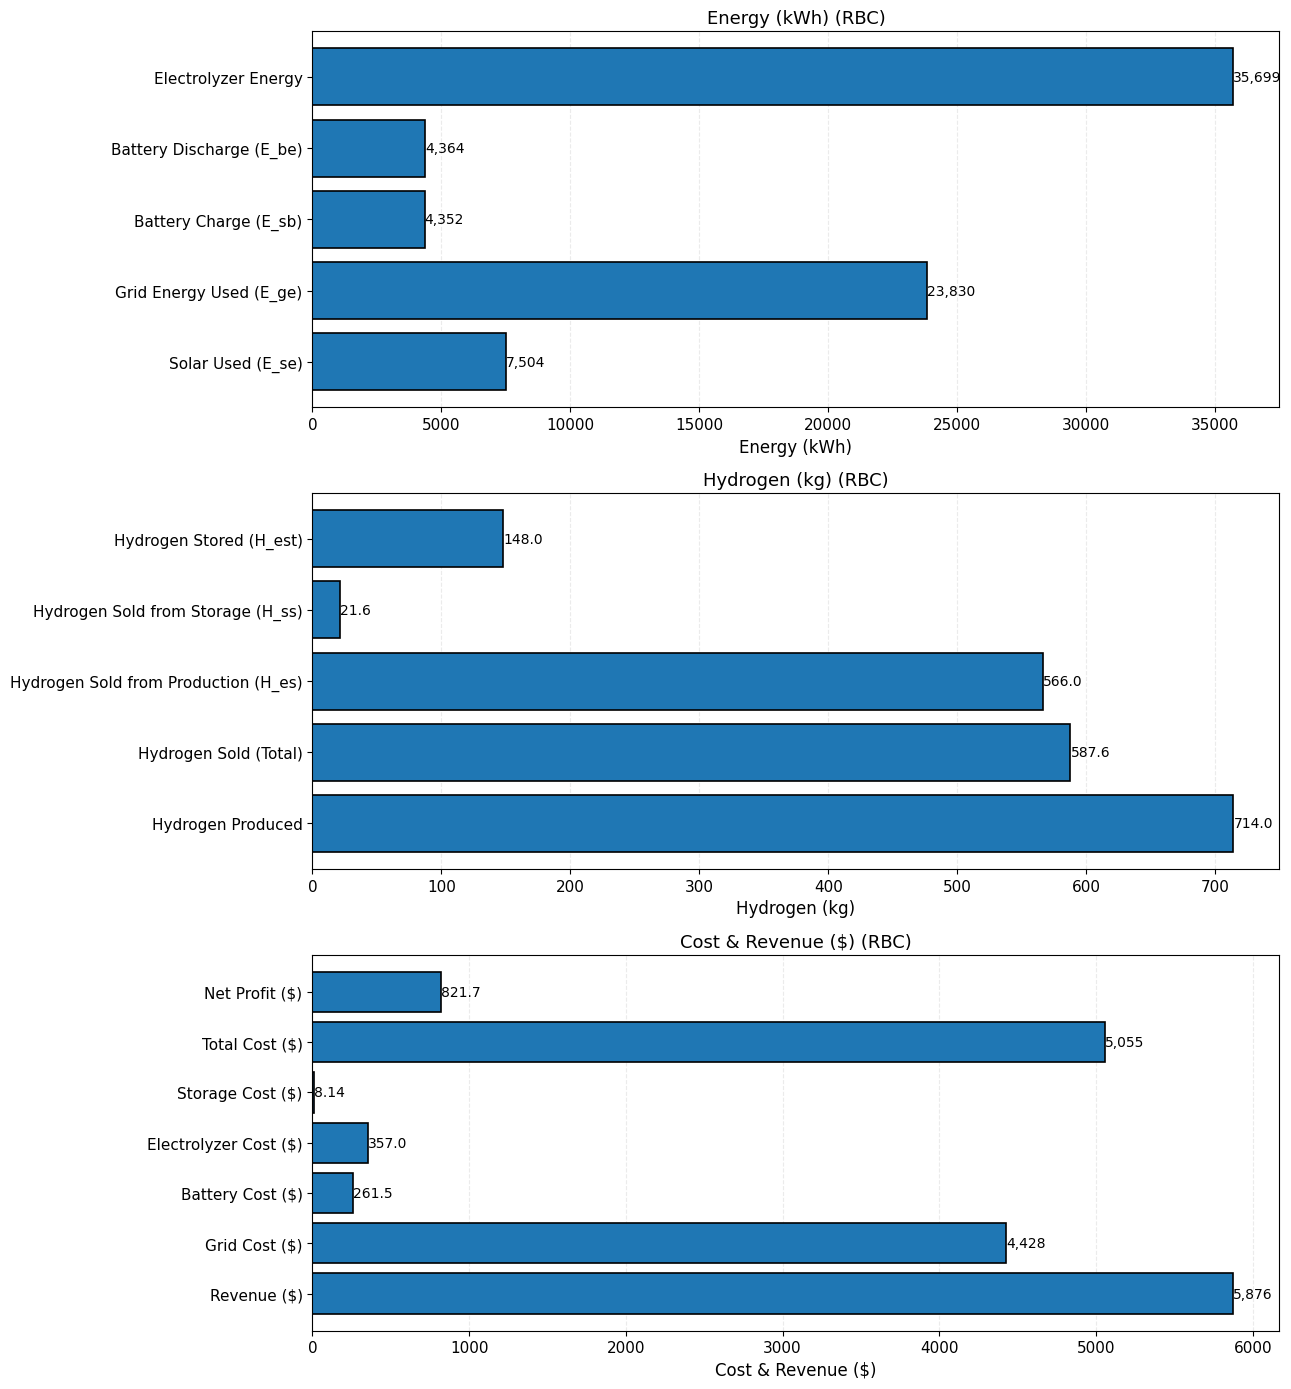

In [13]:
# Example usage (uncomment to run):
logs_rbc, kpis_rbc = demo_rbc()

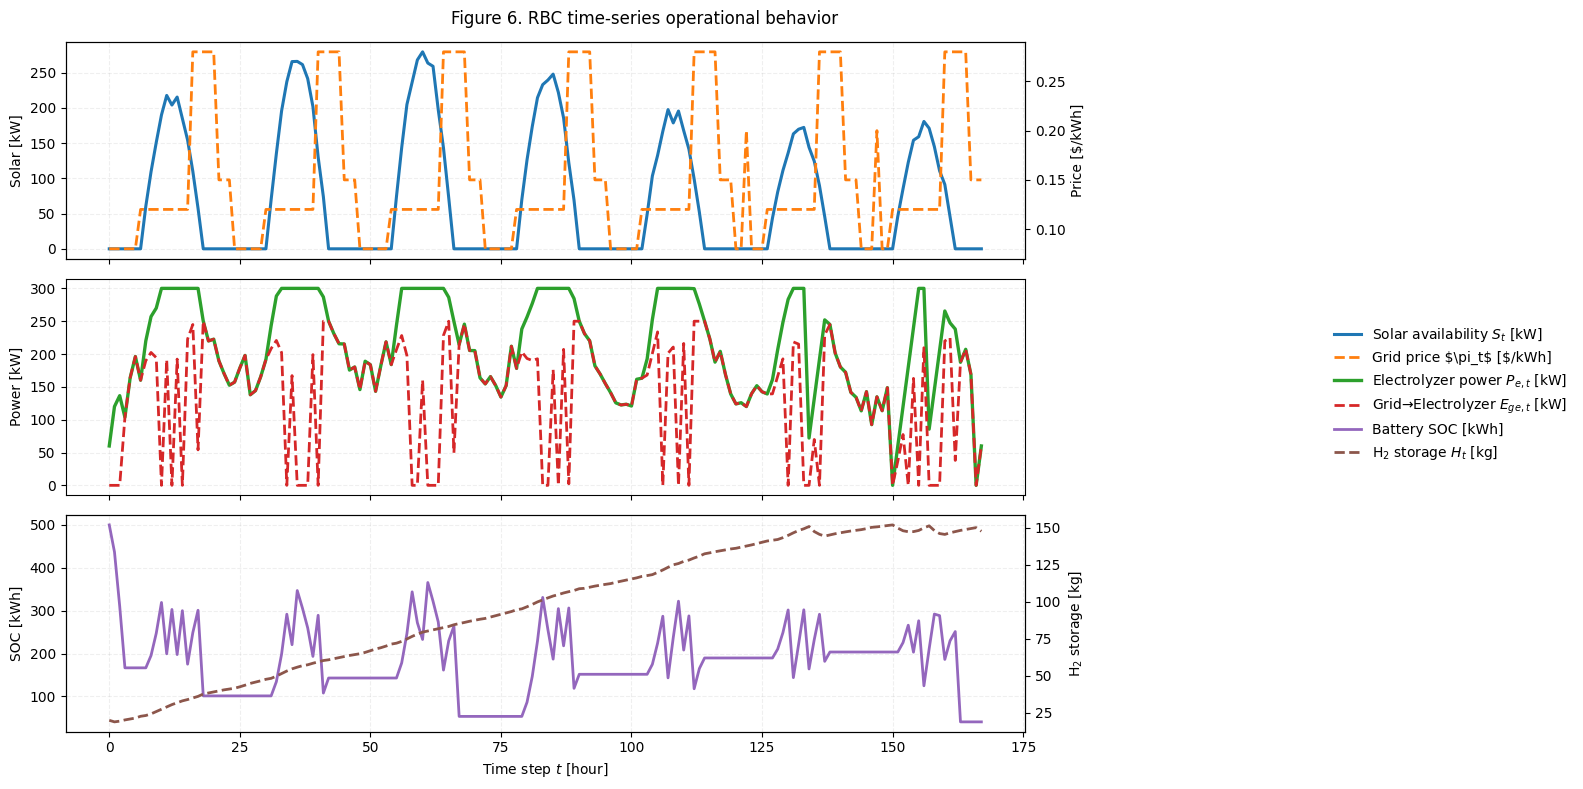

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def plot_fig6_rbc_timeseries(logs_rbc, savepath=None, show=True):

    t = np.arange(len(logs_rbc["P_elec"]))

    solar = np.asarray(logs_rbc["solar"], dtype=float)
    P_elec = np.asarray(logs_rbc["P_elec"], dtype=float)
    E_ge   = np.asarray(logs_rbc["E_ge"], dtype=float)
    SOC    = np.asarray(logs_rbc["SOC"], dtype=float)
    H_store= np.asarray(logs_rbc["H_store"], dtype=float)

    price = np.array([real_grid_price(int(k)) for k in t], dtype=float)

    # Consistent color palette
    COL_SOLAR = "#1f77b4"
    COL_PRICE = "#ff7f0e"
    COL_ELEC  = "#2ca02c"
    COL_GRID  = "#d62728"
    COL_SOC   = "#9467bd"
    COL_H2    = "#8c564b"

    fig, axs = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
    fig.suptitle("Figure 6. RBC time-series operational behavior", y=0.98)

    # -------------------------
    # (a) Solar + Price
    # -------------------------
    ax = axs[0]
    l1 = ax.plot(t, solar, color=COL_SOLAR, linewidth=2.2,
                 label="Solar availability $S_t$ [kW]")
    ax.set_ylabel("Solar [kW]")
    ax.grid(True, alpha=0.2, linestyle="--")

    ax_r = ax.twinx()
    l2 = ax_r.plot(t, price, color=COL_PRICE, linestyle="--", linewidth=2.0,
                   label="Grid price $\\pi_t$ [$/kWh]")
    ax_r.set_ylabel("Price [$/kWh]")

    # -------------------------
    # (b) Electrolyzer + Grid
    # -------------------------
    ax = axs[1]
    l3 = ax.plot(t, P_elec, color=COL_ELEC, linewidth=2.4,
                 label="Electrolyzer power $P_{e,t}$ [kW]")
    l4 = ax.plot(t, E_ge, color=COL_GRID, linestyle="--", linewidth=2.0,
                 label="Grid→Electrolyzer $E_{ge,t}$ [kW]")
    ax.set_ylabel("Power [kW]")
    ax.grid(True, alpha=0.2, linestyle="--")

    # -------------------------
    # (c) SOC + H2 storage
    # -------------------------
    ax = axs[2]
    l5 = ax.plot(t, SOC, color=COL_SOC, linewidth=2.0,
                 label="Battery SOC [kWh]")
    ax.set_ylabel("SOC [kWh]")
    ax.grid(True, alpha=0.2, linestyle="--")

    ax_r = ax.twinx()
    l6 = ax_r.plot(t, H_store, color=COL_H2, linestyle="--", linewidth=2.0,
                   label="H$_2$ storage $H_t$ [kg]")
    ax_r.set_ylabel("H$_2$ storage [kg]")

    axs[2].set_xlabel("Time step $t$ [hour]")

    # -------------------------
    # Global legend outside
    # -------------------------
    lines = l1 + l2 + l3 + l4 + l5 + l6
    labels = [line.get_label() for line in lines]

    fig.legend(lines, labels,
               loc="center left",
               bbox_to_anchor=(1.02, 0.5),
               frameon=False)

    plt.tight_layout(rect=[0, 0, 0.85, 1])

    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")

    if show:
        plt.show()

    plt.close(fig)


# Example:
# logs_rbc = run_rbc()
plot_fig6_rbc_timeseries(logs_rbc, savepath="fig6_rbc_timeseries.png")